In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
df=pd.read_csv('data.csv')


In [36]:
# lista de columnas a eliminar
cols_to_drop = ['ALEAT', 'ID','VT']  # reemplaza por los nombres reales

# hacer el drop
df = df.drop(columns=cols_to_drop)

#renombrar columnas
df.rename(columns={'V31_P': 'V31'}, inplace=True)
df.rename(columns={'V31_P.1': 'V31_P'}, inplace=True)

# verificar
print(df.columns)


Index(['OBJ', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30',
       'V31', 'V1_P', 'V2_P', 'V3_P', 'V4_P', 'V5_P', 'V6_P', 'V7_P', 'V8_P',
       'V9_P', 'V10_P', 'V11_P', 'V12_P', 'V13_P', 'V14_P', 'V15_P', 'V16_P',
       'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P',
       'V25_P', 'V26_P', 'V27_P', 'V28_P', 'V29_P', 'V30_P', 'V31_P'],
      dtype='object')


OBJ
NO    0.7381
SI    0.2619
Name: proportion, dtype: float64


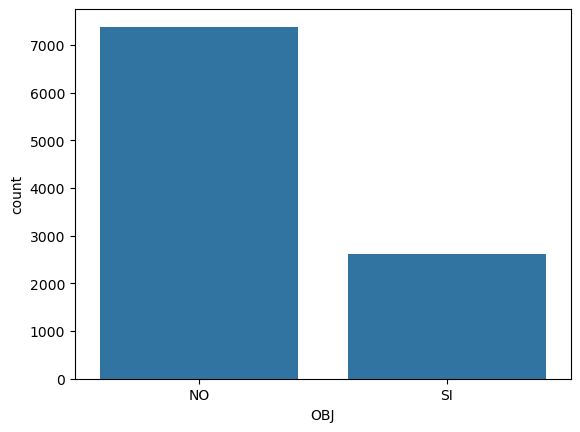

In [37]:
print(df['OBJ'].value_counts(normalize=True))  # distribución
sns.countplot(x='OBJ', data=df)
plt.show()
#tenemos una desproporcion en la distribucion de la variable objetivo

In [38]:
#Una columna constante (todos sus valores son 0, 1, o el mismo número) no aporta ninguna información predictiva, porque no explica varianza.
#Además, puede hacer que algoritmos fallen (como PCA o regresión con inversa de matriz).
#Incluso en árboles, solo agrega peso computacional sin beneficio.
print(df['V14'].describe())
print(df['V14_P'].describe())


count    10000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: V14, dtype: float64
count    10000.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: V14_P, dtype: float64


In [39]:
# lista de columnas a eliminar
cols_to_drop = ['V14', 'V14_P']  # reemplaza por los nombres reales

# hacer el drop
df = df.drop(columns=cols_to_drop)

# verificar
print(df.columns)

Index(['OBJ', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31',
       'V1_P', 'V2_P', 'V3_P', 'V4_P', 'V5_P', 'V6_P', 'V7_P', 'V8_P', 'V9_P',
       'V10_P', 'V11_P', 'V12_P', 'V13_P', 'V15_P', 'V16_P', 'V17_P', 'V18_P',
       'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V26_P',
       'V27_P', 'V28_P', 'V29_P', 'V30_P', 'V31_P'],
      dtype='object')


In [40]:
#Separar grupos de datos en absolutos y relativos
columnas_absolutas=[col for col in df.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
columnas_relativas=[col for col in df.columns if '_P' in col]
#transformar variable objetivo en 1 y 0 para evitar posibles errores en modelos que no lo soporten
df['OBJ']=df['OBJ'].map({'NO':0,'SI':1})

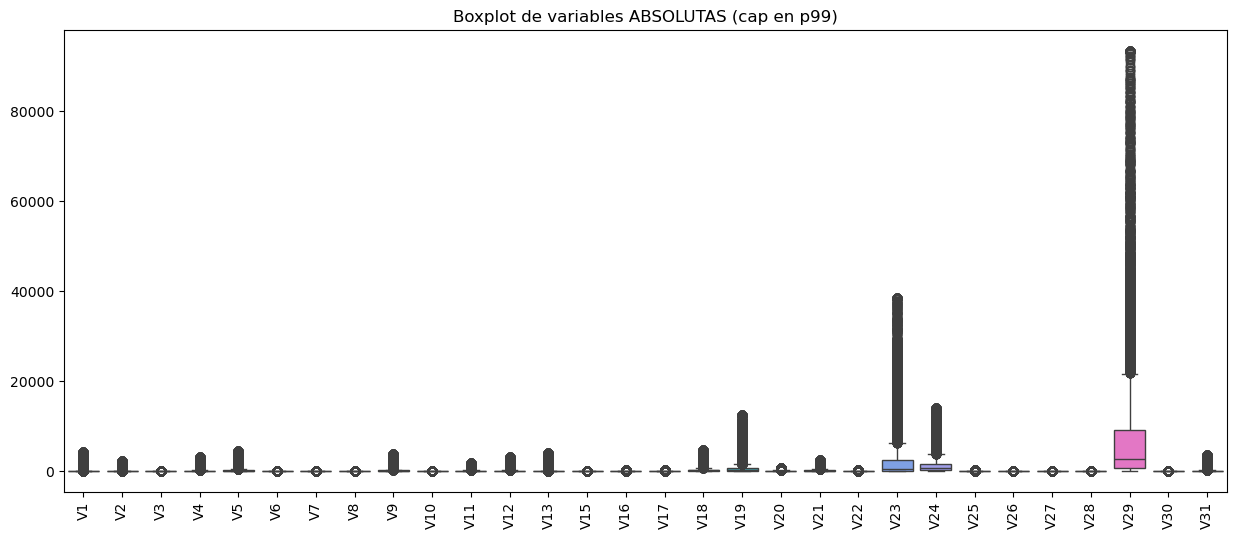

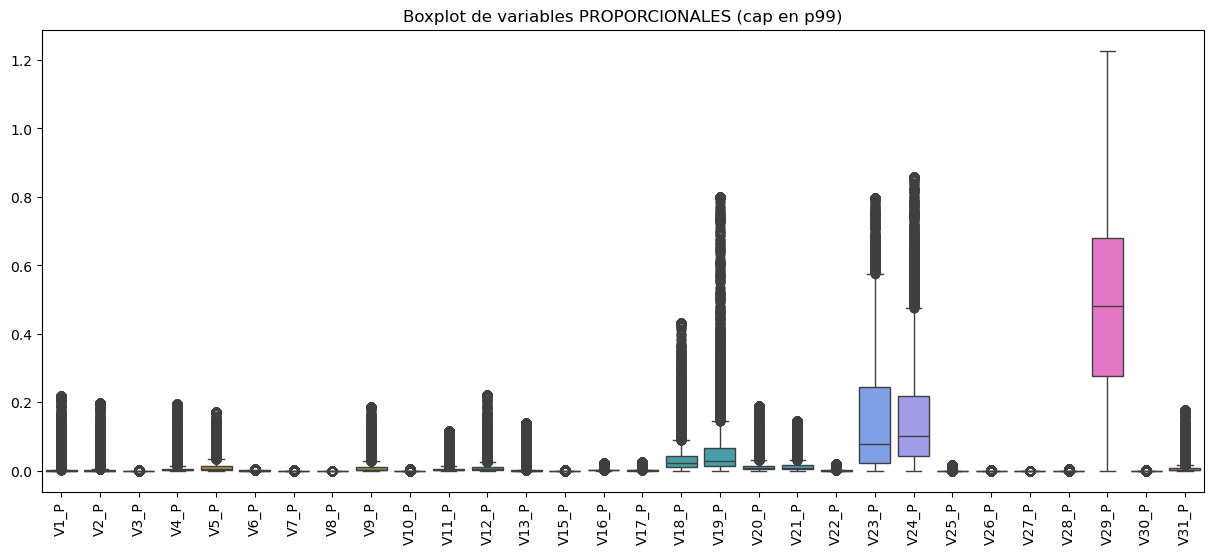

In [41]:

# ==========================
# 2️⃣ Boxplots
# ==========================
# Para evitar plots deformados por outliers extremos, limitamos a p99
def cap_outliers(df_subset):
    capped = df_subset.copy()
    for col in capped.columns:
        cap = capped[col].quantile(0.99)
        capped[col] = np.where(capped[col] > cap, cap, capped[col])
    return capped

# Boxplot variables absolutas
plt.figure(figsize=(15,6))
sns.boxplot(data=cap_outliers(df[columnas_absolutas]))
plt.title('Boxplot de variables ABSOLUTAS (cap en p99)')
plt.xticks(rotation=90)
plt.show()

# Boxplot variables proporcionales
plt.figure(figsize=(15,6))
sns.boxplot(data=cap_outliers(df[columnas_relativas]))
plt.title('Boxplot de variables PROPORCIONALES (cap en p99)')
plt.xticks(rotation=90)
plt.show()


📊 Análisis exploratorio de las variables

Se han separado las variables en absolutas (medidas directas) y relativas (porcentajes o proporciones con _P).

También se transformó la variable objetivo OBJ a 0 y 1 para facilitar su uso en modelos de machine learning.

A continuación se muestra la estadística descriptiva completa de ambos grupos de variables para entender su comportamiento.

In [42]:
# Mostrar estadística descriptiva de las variables absolutas
print("Descripción de variables absolutas:")
display(df[columnas_absolutas].describe().transpose())

# Mostrar estadística descriptiva de las variables relativas
print("Descripción de variables relativas:")
display(df[columnas_relativas].describe().transpose())


Descripción de variables absolutas:


,count,mean,std,min,25%,50%,75%,max
V1,10000.0,261.039200,1058.929785,0.0,0.000000,0.000000,15.531321,25628.988900
V2,10000.0,124.314067,786.846001,0.0,0.000000,0.295540,13.766102,32962.461090
V3,10000.0,0.953652,28.051622,0.0,0.000000,0.000000,0.000000,2228.616420
V4,10000.0,169.008322,979.155195,0.0,0.335424,6.189753,51.979846,62724.729750
V5,10000.0,281.740473,1189.587221,0.0,5.548826,31.308841,149.541211,55157.305830
V6,10000.0,3.211213,8.988382,0.0,0.046440,0.480831,2.512911,279.450335
V7,10000.0,1.618930,18.507076,0.0,0.000000,0.000000,0.000000,694.292589
V8,10000.0,0.011950,0.183108,0.0,0.000000,0.000000,0.000000,9.814952
V9,10000.0,242.595147,826.542184,0.0,1.305022,19.945343,124.936739,26714.988230
V10,10000.0,3.165013,48.091501,0.0,0.000000,0.000000,0.000000,3241.502288


Descripción de variables relativas:


,count,mean,std,min,25%,50%,75%,max
V1_P,10000.0,0.011561,0.051899,0.0,0.000000,0.000000,0.001081,2.310788
V2_P,10000.0,0.010526,0.047925,0.0,0.000000,0.000032,0.001406,1.815782
V3_P,10000.0,0.000147,0.003794,0.0,0.000000,0.000000,0.000000,0.248522
V4_P,10000.0,0.011920,0.046286,0.0,0.000085,0.000891,0.005701,1.234262
V5_P,10000.0,0.015505,0.044195,0.0,0.001782,0.005259,0.014044,1.964142
V6_P,10000.0,0.000288,0.002900,0.0,0.000014,0.000079,0.000202,0.205859
V7_P,10000.0,0.000110,0.001351,0.0,0.000000,0.000000,0.000000,0.045974
V8_P,10000.0,0.000001,0.000026,0.0,0.000000,0.000000,0.000000,0.001422
V9_P,10000.0,0.014761,0.062617,0.0,0.000430,0.002897,0.011473,3.857594
V10_P,10000.0,0.000281,0.005438,0.0,0.000000,0.000000,0.000000,0.410565


Asociación entre las variables independientes y la variable objetivo (OBJ) con Chi²

[Variable original]
      ↓
[qcut con q=4]
      ↓
¿≥2 bins? → No → excluir
      ↓
[crosstab con OBJ]
      ↓
¿min cell ≥5? → No → excluir
      ↓
[chi2_contingency]
      ↓
¿p < 0.05? → No → excluir
      ↓
✅ incluir en X_train


Antes de hacer Chi², necesitamos verificar que las variables tengan más de un bin (grupo), porque si no, no hay nada que comparar (no hay tabla de contingencia posible).

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Variables candidatas
variables_candidatas = columnas_absolutas + columnas_relativas

variables_exploratorias = []
excluidas_sin_variacion = []

for col in variables_candidatas:
    try:
        bins = pd.qcut(df[col], q=4, labels=False, duplicates='drop')
        n_bins = bins.nunique()
        if n_bins > 1:
            variables_exploratorias.append(col)
        else:
            excluidas_sin_variacion.append(col)
    except Exception as e:
        excluidas_sin_variacion.append(col)

print("Variables excluidas por no tener suficiente variación (solo 1 bin):")
print(excluidas_sin_variacion)

print("\nVariables que pasaron a validación Chi² (≥2 bins):")
print(variables_exploratorias)



Variables excluidas por no tener suficiente variación (solo 1 bin):
['V3', 'V7', 'V8', 'V10', 'V15', 'V26', 'V27', 'V28', 'V30', 'V3_P', 'V7_P', 'V8_P', 'V10_P', 'V15_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P']

Variables que pasaron a validación Chi² (≥2 bins):
['V1', 'V2', 'V4', 'V5', 'V6', 'V9', 'V11', 'V12', 'V13', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V29', 'V31', 'V1_P', 'V2_P', 'V4_P', 'V5_P', 'V6_P', 'V9_P', 'V11_P', 'V12_P', 'V13_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V29_P', 'V31_P']


In [44]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# ==============================================================
# 1️⃣ Crear copia temporal del dataframe para el análisis Chi²
# ==============================================================

df_temp = df.copy()
aplicaron_log = []

for col in columnas_absolutas + columnas_relativas:
    # Winsorizing al 1% y 99%
    q01 = df_temp[col].quantile(0.01)
    q99 = df_temp[col].quantile(0.99)
    df_temp[col] = df_temp[col].clip(lower=q01, upper=q99)
    
    # Log si todos los valores son positivos después del clip
    if (df_temp[col] > 0).all():
        df_temp[col] = np.log(df_temp[col])
        aplicaron_log.append(col)

print("✅ Winsorizing aplicado (1%-99%) en todas las variables.")
print("✅ Log aplicado en las siguientes variables (solo si >0):")
print(aplicaron_log)

# ==============================================================
# 2️⃣ Exploración: verificar al menos 2 bins para el Chi²
# ==============================================================

variables_candidatas = columnas_absolutas + columnas_relativas

variables_exploratorias = []
excluidas_sin_variacion = []

for col in variables_candidatas:
    try:
        bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
        n_bins = bins.nunique()
        if n_bins > 1:
            variables_exploratorias.append(col)
        else:
            excluidas_sin_variacion.append(col)
    except Exception as e:
        excluidas_sin_variacion.append(col)

print("\n❌ Variables excluidas por no tener suficiente variación (solo 1 bin):")
print(excluidas_sin_variacion)

print("\n✅ Variables que pasaron a validación Chi² (≥2 bins):")
print(variables_exploratorias)


✅ Winsorizing aplicado (1%-99%) en todas las variables.
✅ Log aplicado en las siguientes variables (solo si >0):
['V19', 'V24', 'V19_P', 'V24_P']

❌ Variables excluidas por no tener suficiente variación (solo 1 bin):
['V3', 'V7', 'V8', 'V10', 'V15', 'V26', 'V27', 'V28', 'V30', 'V3_P', 'V7_P', 'V8_P', 'V10_P', 'V15_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P']

✅ Variables que pasaron a validación Chi² (≥2 bins):
['V1', 'V2', 'V4', 'V5', 'V6', 'V9', 'V11', 'V12', 'V13', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V29', 'V31', 'V1_P', 'V2_P', 'V4_P', 'V5_P', 'V6_P', 'V9_P', 'V11_P', 'V12_P', 'V13_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V29_P', 'V31_P']


In [45]:
resultados = []

for col in variables_exploratorias:
    try:
        bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
        contingency = pd.crosstab(bins, df['OBJ'])  # importante: con OBJ original
        n_bins = bins.nunique()
        min_cell = contingency.min().min()

        # Frecuencia mínima por celda
        if min_cell < 5:
            resultados.append({
                'Variable': col,
                'Bins': n_bins,
                'Min count': min_cell,
                'Chi2': np.nan,
                'p-value': np.nan,
                'Status': f'Excluida (celda <5)'
            })
            continue

        # Aplicar Chi²
        chi2, p, dof, expected = chi2_contingency(contingency)
        status = 'Significativa' if p < 0.05 else 'No significativa'

        resultados.append({
            'Variable': col,
            'Bins': n_bins,
            'Min count': min_cell,
            'Chi2': chi2,
            'p-value': p,
            'Status': status
        })

    except Exception as e:
        resultados.append({
            'Variable': col,
            'Bins': np.nan,
            'Min count': np.nan,
            'Chi2': np.nan,
            'p-value': np.nan,
            'Status': f'Error: {e}'
        })

# Convertir a DataFrame ordenado
resultados_df = pd.DataFrame(resultados).sort_values(by='p-value', na_position='last')

# Mostrar tabla final
print("🔍 Resumen del test Chi² por variable:")
display(resultados_df)

# Variables seleccionadas para el modelo
variables_finales = resultados_df.loc[resultados_df['Status'] == 'Significativa', 'Variable'].tolist()

print("\n✅ Variables seleccionadas para el modelo final (Chi² significativas):")
print(variables_finales)


🔍 Resumen del test Chi² por variable:


,Variable,Bins,Min count,Chi2,p-value,Status
22,V2_P,3,639,131.531874,2.742941e-29,Significativa
1,V2,3,646,131.075014,3.446849e-29,Significativa
23,V4_P,4,491,133.868456,7.930891e-29,Significativa
9,V16,4,496,127.155888,2.217860e-27,Significativa
2,V4,4,477,123.737516,1.208923e-26,Significativa
35,V21_P,4,492,110.353720,9.208969e-24,Significativa
36,V22_P,3,672,105.085414,1.517024e-23,Significativa
20,V31,4,474,97.963156,4.260000e-21,Significativa
30,V16_P,4,508,96.791492,7.608035e-21,Significativa
14,V21,4,488,92.115505,7.693409e-20,Significativa



✅ Variables seleccionadas para el modelo final (Chi² significativas):
['V2_P', 'V2', 'V4_P', 'V16', 'V4', 'V21_P', 'V22_P', 'V31', 'V16_P', 'V21', 'V22', 'V19', 'V23', 'V31_P', 'V18', 'V6', 'V19_P', 'V5', 'V29', 'V11', 'V5_P', 'V6_P', 'V12', 'V20', 'V11_P', 'V13', 'V24', 'V18_P', 'V9_P', 'V9', 'V23_P', 'V17_P', 'V17', 'V24_P', 'V13_P', 'V29_P', 'V25', 'V25_P', 'V20_P', 'V12_P']


Revisar graficamente cuales estan con p value mayor a 0.05


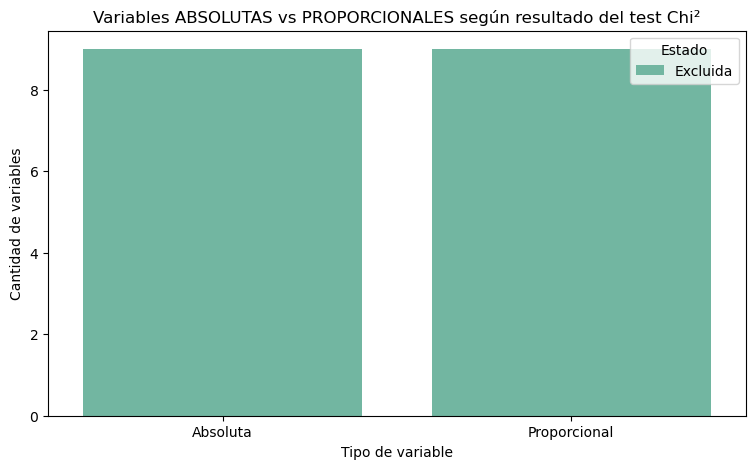

In [46]:
# ======================================================
# 1️⃣ Crear DataFrame para variables sin variación
# ======================================================
df_sin_variacion = pd.DataFrame({
    'Variable': excluidas_sin_variacion,
    'Bins': 1,
    'Min count': np.nan,
    'Chi2': np.nan,
    'p-value': np.nan,
    'Status': 'Excluida (1 bin)'
})

# Marcar tipo
df_sin_variacion['Tipo'] = df_sin_variacion['Variable'].apply(
    lambda x: 'Absoluta' if '_P' not in x else 'Proporcional'
)

# Marcar significancia explícita
df_sin_variacion['Significativa'] = 'Excluida'

# ======================================================
# 2️⃣ Unir con el dataframe de resultados originales
# ======================================================
# (que ya tiene Tipo y Significativa)
df_completo = pd.concat([resultados_df, df_sin_variacion], ignore_index=True)

# ======================================================
# 3️⃣ Hacer conteo final
# ======================================================
counts_final = df_completo.groupby(['Tipo', 'Significativa']).size().reset_index(name='Cantidad')

# ======================================================
# 4️⃣ Gráfico comparativo incluyendo excluidas
# ======================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))
sns.barplot(data=counts_final, x='Tipo', y='Cantidad', hue='Significativa', palette='Set2')
plt.title('Variables ABSOLUTAS vs PROPORCIONALES según resultado del test Chi²')
plt.ylabel('Cantidad de variables')
plt.xlabel('Tipo de variable')
plt.legend(title='Estado')
plt.show()


In [47]:
from scipy.stats import pointbiserialr
import numpy as np
import pandas as pd

# Combinar todas las variables (exploratorias que pasaron bins + las que no)
todas_las_variables = variables_exploratorias + excluidas_sin_variacion

# Lista para guardar resultados
resultados_pb_total = []

for col in todas_las_variables:
    try:
        corr, pval = pointbiserialr(df['OBJ'], df[col])
        status = 'Significativa' if pval < 0.05 else 'No significativa'
        
        resultados_pb_total.append({
            'Variable': col,
            'r_pb': corr,
            'p-value': pval,
            'Status': status
        })
    except Exception as e:
        resultados_pb_total.append({
            'Variable': col,
            'r_pb': np.nan,
            'p-value': np.nan,
            'Status': f'Error: {e}'
        })

# Convertir a DataFrame ordenado
resultados_pb_df_total = pd.DataFrame(resultados_pb_total).sort_values(by='p-value', na_position='last')

# Mostrar tabla
print("📊 Resultados del test punto-biserial en todas las variables:")
display(resultados_pb_df_total)



📊 Resultados del test punto-biserial en todas las variables:


,Variable,r_pb,p-value,Status
2,V4,0.057686,7.801350e-09,Significativa
22,V2_P,0.052559,1.449194e-07,Significativa
23,V4_P,0.046250,3.711102e-06,Significativa
11,V18,0.041480,3.335613e-05,Significativa
35,V21_P,0.038599,1.130080e-04,Significativa
1,V2,0.037323,1.891121e-04,Significativa
9,V16,0.035592,3.709608e-04,Significativa
49,V28,0.034582,5.426212e-04,Significativa
14,V21,0.033947,6.857541e-04,Significativa
18,V25,0.032404,1.191660e-03,Significativa


## Comparación del Chi² vs Punto Biserial

En este análisis se evaluó la asociación de cada variable independiente con la variable objetivo (`OBJ`) utilizando dos enfoques complementarios:

- **Test Chi²:** mide independencia entre categorías formadas mediante binning (qcut), adecuado para identificar diferencias en la distribución entre segmentos.
- **Correlación punto biserial:** mide la relación lineal directa entre la variable continua y la variable binaria `OBJ`.

Algunos hallazgos clave del análisis:

    Varias variables resultaron significativas según el test Chi², reflejando que su distribución discreta difiere entre las clases (por ejemplo, `V4`, `V16`, `V22`).  
    Otras variables mostraron significancia solo bajo el punto biserial (por ejemplo `V15`, `V28`), indicando que, aunque no presentan diferencias claras por bins, sí mantienen una tendencia lineal con `OBJ`.

Además, el análisis evidenció que:

- Las variables excluidas del Chi² (por no poder formar al menos 2 bins) igualmente fueron evaluadas mediante punto biserial, lo que permitió rescatar posibles relaciones lineales que de otra forma hubieran quedado descartadas.
- La comparación lado a lado permite validar la robustez de cada variable, identificando cuáles son significativas en ambos enfoques, y cuáles solo bajo una perspectiva.

Este análisis garantiza que la selección final de variables para el modelo no dependa de un único criterio estadístico, sino de una visión integral, maximizando la capacidad explicativa del conjunto de datos.


In [48]:
# -----------------------------------------------------
# 1️⃣ Preparamos el DataFrame del Chi²
# -----------------------------------------------------
df_chi = resultados_df[['Variable', 'Status', 'p-value']].rename(
    columns={'Status': 'Chi² Status', 'p-value': 'Chi² p-value'}
)

# -----------------------------------------------------
# 2️⃣ Preparamos el DataFrame del punto biserial
# -----------------------------------------------------
df_pb = resultados_pb_df_total[['Variable', 'Status', 'p-value']].rename(
    columns={'Status': 'PuntoBiserial Status', 'p-value': 'PuntoBiserial p-value'}
)

# -----------------------------------------------------
# 3️⃣ Hacemos el merge
# -----------------------------------------------------
df_comparativo = pd.merge(df_chi, df_pb, on='Variable', how='outer')

# Ordenar por nombre de variable o por Chi² p-value
df_comparativo.sort_values(by='Variable', inplace=True)

df_comparativo['Chi² Status'] = df_comparativo['Chi² Status'].fillna('No evaluada (1 bin o excluida)')


# -----------------------------------------------------
# 4️⃣ Mostrar tabla final
# -----------------------------------------------------
print("📊 Comparación del resultado del Chi² vs Punto Biserial:")
display(df_comparativo)


📊 Comparación del resultado del Chi² vs Punto Biserial:


,Variable,Chi² Status,Chi² p-value,PuntoBiserial Status,PuntoBiserial p-value
0,V1,No significativa,4.384827e-01,No significativa,2.394487e-01
1,V10,No evaluada (1 bin o excluida),NaN,No significativa,9.363011e-01
2,V10_P,No evaluada (1 bin o excluida),NaN,No significativa,3.314742e-01
3,V11,Significativa,4.935136e-12,No significativa,9.998242e-02
4,V11_P,Significativa,2.050967e-08,No significativa,1.507780e-01
5,V12,Significativa,7.787469e-11,No significativa,1.367638e-01
6,V12_P,Significativa,3.965901e-02,No significativa,2.189518e-01
7,V13,Significativa,4.483070e-08,No significativa,1.128766e-01
8,V13_P,Significativa,3.606376e-05,No significativa,1.370947e-01
9,V15,No evaluada (1 bin o excluida),NaN,Significativa,2.175373e-02


## Criterio final para selección de variables

Para la etapa de selección de variables, se aplicaron dos enfoques complementarios:

- **Test Chi²:** evalúa la independencia entre la variable categorizada (mediante binning) y la variable objetivo binaria `OBJ`.
- **Correlación punto biserial:** mide la relación lineal directa entre la variable continua y `OBJ`.

El criterio adoptado para conservar variables en el modelo fue **incluir todas aquellas que resultaron significativas en al menos uno de los dos tests**.  
De este modo, se garantiza no descartar variables que puedan aportar capacidad explicativa, ya sea por evidenciar una relación segmentada (detectada por Chi²) o una tendencia lineal (detectada por punto biserial).

Solo se eliminaron las variables que **no mostraron significancia estadística en ninguno de los dos enfoques**, asegurando así un modelo final con el máximo potencial informativo.


In [49]:
# Variables que NO pasaron ninguno de los dos tests:
# es decir, no significativas en Chi² y no significativas en punto biserial
no_significativas_ninguno = df_comparativo[
    ((df_comparativo['Chi² Status'] != 'Significativa') & 
     (df_comparativo['PuntoBiserial Status'] != 'Significativa'))
]['Variable'].tolist()

# Separar en ABS y REL
candidatas_quitar_abs = [v for v in no_significativas_ninguno if v in columnas_absolutas]
candidatas_quitar_rel = [v for v in no_significativas_ninguno if v in columnas_relativas]

print("Variables ABSOLUTAS candidatas a eliminar (no significativas en ninguno de los dos tests):")
print(candidatas_quitar_abs)

print("\nVariables PROPORCIONALES candidatas a eliminar (no significativas en ninguno de los dos tests):")
print(candidatas_quitar_rel)



Variables ABSOLUTAS candidatas a eliminar (no significativas en ninguno de los dos tests):
['V1', 'V10', 'V27', 'V30', 'V7', 'V8']

Variables PROPORCIONALES candidatas a eliminar (no significativas en ninguno de los dos tests):
['V10_P', 'V15_P', 'V1_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P', 'V3_P', 'V7_P', 'V8_P']


Encontrar variables altamente correlacionadas

In [50]:
X_abs = df[columnas_absolutas]
X_p = df[columnas_relativas]

## Análisis de multicolinealidad en variables absolutas

Para garantizar la estabilidad y la interpretabilidad del modelo, se evaluó la multicolinealidad entre las variables absolutas mediante la matriz de correlación de Pearson.

- Se construyó una matriz de correlación absoluta (`corr().abs()`), extrayendo únicamente el triángulo superior para evitar duplicados.
- Se revisaron todas las parejas de variables, utilizando un umbral de **0.90** para identificar posibles redundancias.

El análisis evidenció que **no existieron pares de variables con correlación superior a 0.90**, por lo que no fue necesario eliminar ninguna variable en esta etapa.  
Esto confirma que el conjunto de variables absolutas no presenta problemas de colinealidad alta y puede ser utilizado en el modelo sin riesgo de inestabilidad numérica asociada a variables redundantes.


In [51]:
import numpy as np

# ============================================
# BLOQUE PARA ABSOLUTOS
# ============================================
# Calcular matriz de correlación absoluta
corr_matrix_abs = X_abs.corr().abs()

# Extraer triángulo superior para evitar duplicados
upper_abs = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_abs_corr = [column for column in upper_abs.columns if any(upper_abs[column] > 0.90)]

print("Variables ABSOLUTAS a eliminar por alta correlación (>0.90):", to_drop_abs_corr)

# Eliminar del dataset
X_abs_reduced = X_abs.drop(columns=to_drop_abs_corr)

print("Shape original ABS:", X_abs.shape)
print("Shape reducido ABS:", X_abs_reduced.shape)



Variables ABSOLUTAS a eliminar por alta correlación (>0.90): []
Shape original ABS: (10000, 30)
Shape reducido ABS: (10000, 30)


In [52]:
# ============================================
# BLOQUE PARA RELATIVOS
# ============================================
# Calcular matriz de correlación
corr_matrix_p = X_p.corr().abs()

# Triángulo superior
upper_p = corr_matrix_p.where(np.triu(np.ones(corr_matrix_p.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_p_corr = [column for column in upper_p.columns if any(upper_p[column] > 0.90)]

print("Variables PROPORCIONALES a eliminar por alta correlación (>0.90):", to_drop_p_corr)

# Eliminar del dataset
X_p_reduced = X_p.drop(columns=to_drop_p_corr)

print("Shape original PROP:", X_p.shape)
print("Shape reducido PROP:", X_p_reduced.shape)


Variables PROPORCIONALES a eliminar por alta correlación (>0.90): []
Shape original PROP: (10000, 30)
Shape reducido PROP: (10000, 30)


# Declarar variables con las que se va trabajar

In [53]:
# =====================================
# LIBRERÍAS BÁSICAS
# =====================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# =====================================
# DEFINIR VARIABLES SEGÚN TU DATA
# columnas_absolutas y columnas_relativas deben estar ya definidos:
# Ejemplo:
# columnas_absolutas = ['V1', 'V2', ..., 'V30']
# columnas_relativas = ['V1_P', 'V2_P', ..., 'V30_P']
# =====================================
y=df['OBJ']  # Variable objetivo
x= df[columnas_absolutas + columnas_relativas]
x_trained,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)  # Todas las variables
# =====================================
# DATA ABSOLUTA
# =====================================
# DATA ORIGINAL
X_abs = df[columnas_absolutas]

# DATA FILTRADA (sin variables no significativas ni altamente correlacionadas)
X_abs_filtered = X_abs.drop(columns=list(set(candidatas_quitar_abs + to_drop_abs_corr)))

# Dividir en train/test
X_abs_train, X_abs_test, y_abs_train, y_abs_test = train_test_split(
    X_abs, y, test_size=0.2, stratify=y, random_state=42
)
X_abs_f_train, X_abs_f_test, y_abs_f_train, y_abs_f_test = train_test_split(
    X_abs_filtered, y, test_size=0.2, stratify=y, random_state=42
)

# =====================================
# DATA RELATIVA
# =====================================
# DATA ORIGINAL
X_p = df[columnas_relativas]

# DATA FILTRADA
X_p_filtered = X_p.drop(columns=list(set(candidatas_quitar_rel + to_drop_p_corr)))

# Dividir en train/test
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y, test_size=0.2, stratify=y, random_state=42
)
X_p_f_train, X_p_f_test, y_p_f_train, y_p_f_test = train_test_split(
    X_p_filtered, y, test_size=0.2, stratify=y, random_state=42
)


# Elección del dataset


In [54]:
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# =====================================
# LISTA DE DATASETS
# =====================================
datasets = [
    ("ORIG", x_trained, y_train, x_test, y_test),
    ("ABS ORIG", X_abs_train, y_abs_train, X_abs_test, y_abs_test),
    ("ABS FILT", X_abs_f_train, y_abs_f_train, X_abs_f_test, y_abs_f_test),
    ("PROP ORIG", X_p_train, y_p_train, X_p_test, y_p_test),
    ("PROP FILT", X_p_f_train, y_p_f_train, X_p_f_test, y_p_f_test)
]

# =====================================
# SCORINGS COMO COLUMNAS
# =====================================
scorings = ['accuracy', 'roc_auc', 'average_precision', 'f1', 'f1_macro', 'f1_weighted']

# =====================================
# PIPELINE SIMPLE
# =====================================
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1, penalty='l2', solver='liblinear', class_weight='balanced', random_state=42))
])

# =====================================
# LOOP PRINCIPAL
# =====================================
results = []

for (dataset_name, X_train, y_train, X_test, y_test) in datasets:
    dataset_result = {'Dataset': dataset_name}
    
    # Guardar Mean_CV_Score de cada scoring
    for scoring in scorings:
        grid = GridSearchCV(pipe_lr, {}, cv=5, scoring=scoring, n_jobs=-1)
        grid.fit(X_train, y_train)
        dataset_result[f"Mean_CV_Score_{scoring}"] = grid.best_score_
    
    # Calcular métricas finales en test set
    y_pred = grid.best_estimator_.predict(X_test)
    dataset_result.update({
        'Precision_0': precision_score(y_test, y_pred, pos_label=0),
        'Recall_0': recall_score(y_test, y_pred, pos_label=0),
        'F1_0': f1_score(y_test, y_pred, pos_label=0),
        'Precision_1': precision_score(y_test, y_pred, pos_label=1),
        'Recall_1': recall_score(y_test, y_pred, pos_label=1),
        'F1_1': f1_score(y_test, y_pred, pos_label=1)
    })
    
    results.append(dataset_result)

# =====================================
# CONSOLIDAR EN DATAFRAME FINAL
# =====================================
df_dataset_results = pd.DataFrame(results)
display(df_dataset_results)



,Dataset,Mean_CV_Score_accuracy,Mean_CV_Score_roc_auc,Mean_CV_Score_average_precision,Mean_CV_Score_f1,Mean_CV_Score_f1_macro,Mean_CV_Score_f1_weighted,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
0,ORIG,0.619500,0.596580,0.333354,0.399994,0.560519,0.636969,0.766827,0.648374,0.702643,0.309840,0.444656,0.365204
1,ABS ORIG,0.675875,0.595439,0.341502,0.349399,0.566771,0.670294,0.770190,0.794715,0.782261,0.364780,0.332061,0.347652
2,ABS FILT,0.680125,0.596014,0.344920,0.357132,0.572098,0.674475,0.770642,0.796748,0.783478,0.367089,0.332061,0.348697
3,PROP ORIG,0.605625,0.582455,0.318823,0.386892,0.547924,0.624615,0.771590,0.647696,0.704236,0.316689,0.459924,0.375097
4,PROP FILT,0.606875,0.586319,0.321908,0.387426,0.548823,0.625688,0.773646,0.648374,0.705492,0.319790,0.465649,0.379176


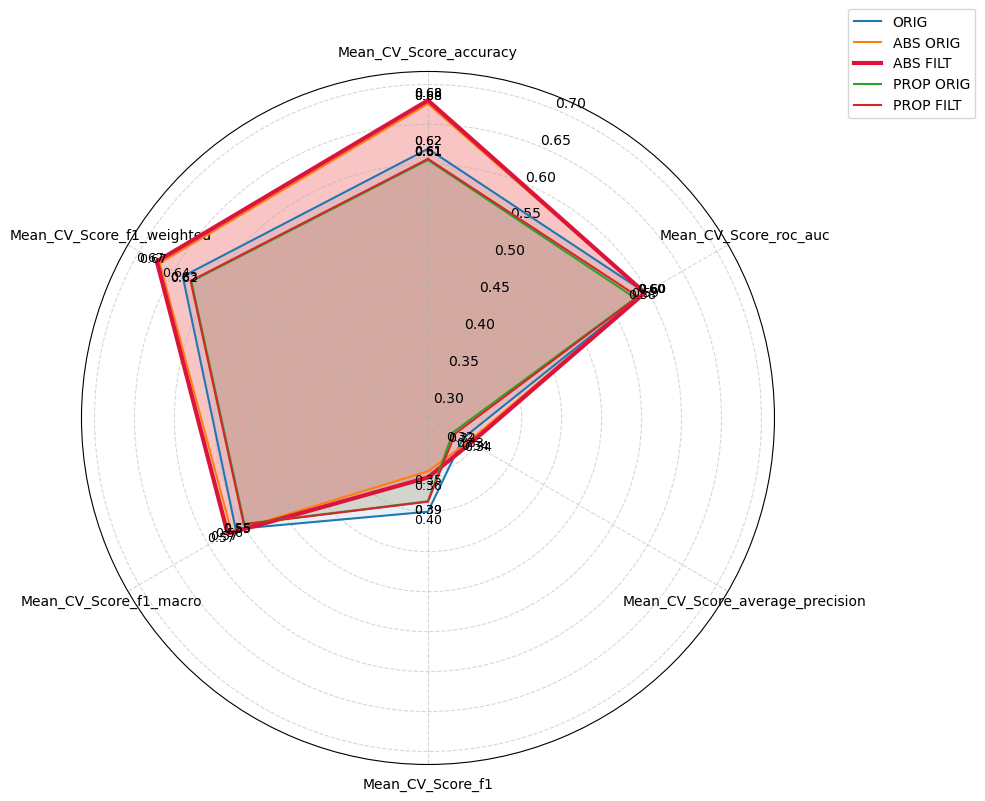

In [55]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Mean_CV_Score_accuracy', 'Mean_CV_Score_roc_auc', 
          'Mean_CV_Score_average_precision', 'Mean_CV_Score_f1','Mean_CV_Score_f1_macro','Mean_CV_Score_f1_weighted']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# ==============================
# CALCULAR RANGO AUTOMÁTICO
# ==============================
all_values = df_dataset_results[labels].values.flatten()
min_val = all_values.min()
max_val = all_values.max()
padding = (max_val - min_val) * 0.1
lower = max(0, min_val - padding)
upper = min(1, max_val + padding)

# ==============================
# PLOT RADAR
# ==============================
fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))

for i, row in df_dataset_results.iterrows():
    values = row[labels].tolist()
    values += values[:1]
    dataset_name = row['Dataset']
    
    # Destacar ABS FILT
    if dataset_name == 'ABS FILT':
        ax.plot(angles, values, linewidth=3, linestyle='-', label=dataset_name, color='crimson')
        ax.fill(angles, values, alpha=0.2, color='crimson')
    else:
        ax.plot(angles, values, linewidth=1.5, label=dataset_name)
        ax.fill(angles, values, alpha=0.1)
    
    # Mostrar valores exactos en el gráfico
    for angle, val in zip(angles, values):
        ax.text(angle, val + 0.01, f"{val:.2f}", size=9, ha='center', va='center')

# Ajustes
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(lower, upper)
plt.title("", fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


“Dado que el desbalance puede corregirse eficazmente en etapas posteriores mediante técnicas como sampling o ajuste de class_weight, la selección del dataset se realizó priorizando métricas globales de rendimiento. Así, se eligió ABS FILT por presentar el mejor promedio entre accuracy, f1_weighted y average_precision, garantizando una base robusta sobre la cual afinar el desempeño en la clase minoritaria con tuning especializado.”

### Eleccion de Sampler y Scaler utilizando diferentes scorings para ver trade offs


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

# ==============================
# CONFIGURAR GRID
# ==============================
param_grid = {
    'sampler': [SMOTE(), RandomOverSampler(), RandomUnderSampler(), SMOTETomek(), SMOTEENN()],
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler(), QuantileTransformer(output_distribution='normal', random_state=42)]
}

# ==============================
# MODELO BASE
# ==============================
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', SMOTE()),
    ('model', LogisticRegression(
        C=1, penalty='l2', solver='liblinear',
        class_weight='balanced', random_state=42, max_iter=1000))
])

# ==============================
# DIFERENTES SCORINGS A PROBAR
# ==============================
scorings = ['accuracy', 'roc_auc', 'f1', 'average_precision']

# ==============================
# DATAFRAME PARA CONSOLIDAR RESULTADOS
# ==============================
results_list = []

for scoring in scorings:
    print(f"\n🚀 Running GridSearchCV with scoring = {scoring}")
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring=scoring,
        cv=5,
        n_jobs=-1,
        verbose=2,
        return_train_score=False
    )
    grid.fit(X_abs_f_train, y_abs_f_train)
    
    # Evaluar en test
    y_pred = grid.predict(X_abs_f_test)
    y_proba = grid.predict_proba(X_abs_f_test)[:,1]
    
    precision = precision_score(y_abs_f_test, y_pred)
    recall = recall_score(y_abs_f_test, y_pred)
    f1 = f1_score(y_abs_f_test, y_pred)
    average_precision = average_precision_score(y_abs_f_test, y_proba)
    roc_auc = roc_auc_score(y_abs_f_test, y_proba)
    accuracy = np.mean(y_pred == y_abs_f_test)
    
    # Guardar en lista
    results_list.append({
        'scoring': scoring,
        'best_sampler': grid.best_params_['sampler'],
        'best_scaler': grid.best_params_['scaler'],
        'best_cv_score': grid.best_score_,
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'test_f1': f1,
        'test_avg_precision': average_precision,
        'test_roc_auc': roc_auc
    })

# ==============================
# CONSOLIDAR EN UN DATAFRAME
# ==============================
results_df = pd.DataFrame(results_list)

print("\n📊 Comparativo final por scoring:")
display(results_df)



🚀 Running GridSearchCV with scoring = accuracy
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🚀 Running GridSearchCV with scoring = roc_auc
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🚀 Running GridSearchCV with scoring = f1
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🚀 Running GridSearchCV with scoring = average_precision
Fitting 5 folds for each of 20 candidates, totalling 100 fits

📊 Comparativo final por scoring:


,scoring,best_sampler,best_scaler,best_cv_score,test_accuracy,test_precision,test_recall,test_f1,test_avg_precision,test_roc_auc
0,accuracy,RandomOverSampler(),MinMaxScaler(),0.684500,0.6830,0.367150,0.290076,0.324094,0.330061,0.579573
1,roc_auc,SMOTETomek(),QuantileTransformer(output_distribution='norma...,0.610891,0.5760,0.320796,0.553435,0.406162,0.342382,0.596340
2,f1,SMOTEENN(),QuantileTransformer(output_distribution='norma...,0.427854,0.5085,0.299913,0.656489,0.411730,0.337021,0.592902
3,average_precision,RandomUnderSampler(),QuantileTransformer(output_distribution='norma...,0.361542,0.5890,0.332960,0.566794,0.419492,0.336036,0.597820


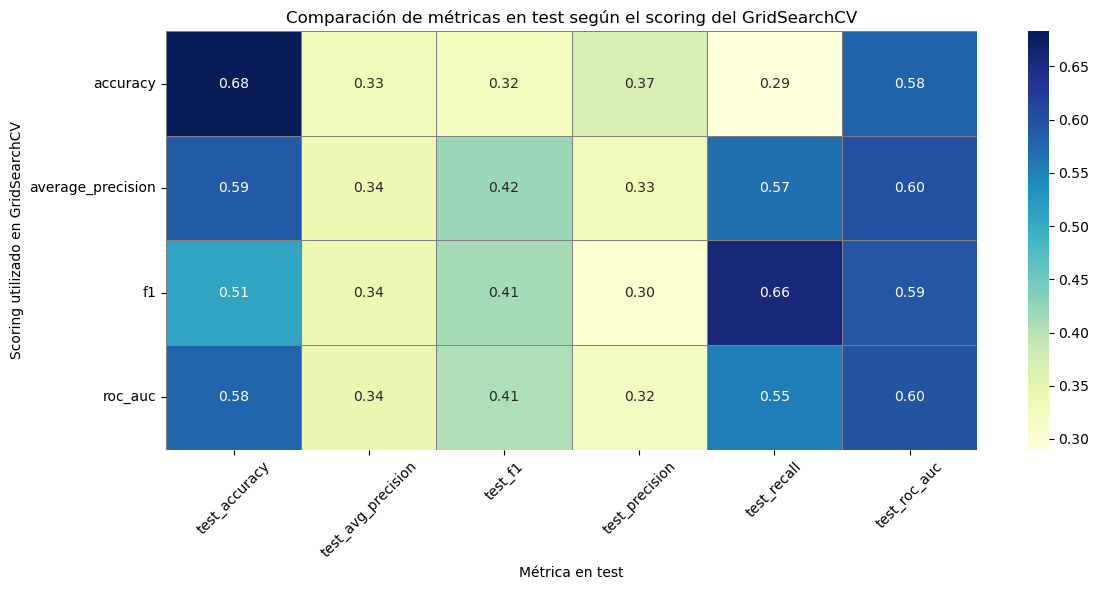

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# FORMATEAR DATAFRAME PARA HEATMAP
# ==============================
heatmap_df = results_df[['scoring', 
                         'test_accuracy', 
                         'test_precision', 
                         'test_recall', 
                         'test_f1', 
                         'test_avg_precision', 
                         'test_roc_auc']]

heatmap_df_melted = heatmap_df.melt(id_vars='scoring', 
                                    var_name='Metric', 
                                    value_name='Score')

# ==============================
# PLOT HEATMAP
# ==============================
plt.figure(figsize=(12,6))
pivot_table = heatmap_df_melted.pivot(index='scoring', columns='Metric', values='Score')

sns.heatmap(pivot_table, 
            annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5, linecolor='gray')

plt.title("Comparación de métricas en test según el scoring del GridSearchCV")
plt.ylabel("Scoring utilizado en GridSearchCV")
plt.xlabel("Métrica en test")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## mejorar parametros del modelo

> Baseline elegido: LogisticRegression con `C=0.1`, `penalty='l1'`, `solver='saga'`, `class_weight='balanced'`,
optimizado con `f1`.  
Maximiza el balance entre precision y recall (recall≈0.63, f1≈0.41) para threshold 0.5, 
ideal como referencia antes de probar RandomForest o XGBoost.



🚀 Ajustando LogisticRegression con scoring = f1
Fitting 5 folds for each of 80 candidates, totalling 400 fits

🚀 Ajustando LogisticRegression con scoring = average_precision
Fitting 5 folds for each of 80 candidates, totalling 400 fits

🚀 Ajustando LogisticRegression con scoring = accuracy
Fitting 5 folds for each of 80 candidates, totalling 400 fits


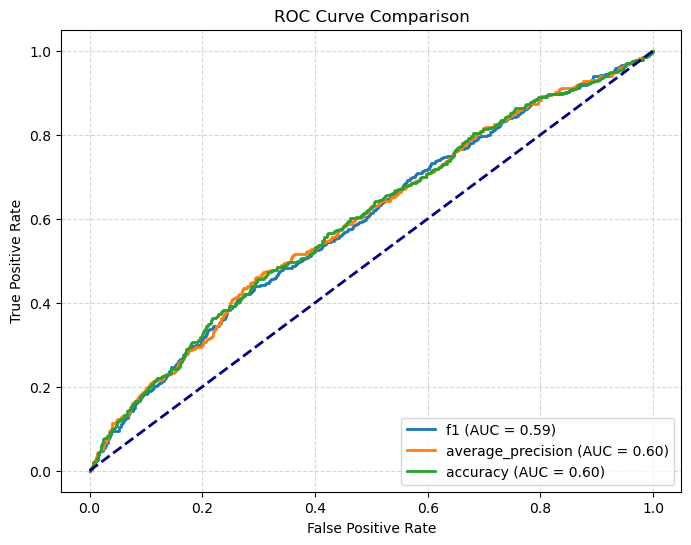

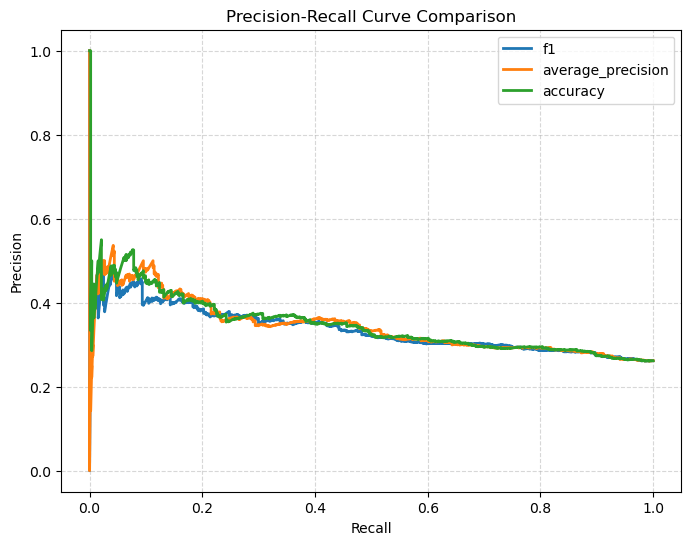


==== LogisticRegression optimizado con f1 ====
Best Params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'saga'}
Best CV Score (f1): 0.4312888627470395
Classification Report en test set:
              precision    recall  f1-score   support

           0       0.79      0.47      0.59      1476
           1       0.30      0.64      0.41       524

    accuracy                           0.52      2000
   macro avg       0.54      0.56      0.50      2000
weighted avg       0.66      0.52      0.54      2000


==== LogisticRegression optimizado con average_precision ====
Best Params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV Score (average_precision): 0.3635767477771345
Classification Report en test set:
              precision    recall  f1-score   support

           0       0.79      0.47      0.59      1476
           1       0.30      0.64      0.41       524

    accur

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# ==============================
# DEFINIR PIPELINE Y PARAM GRID COMÚN
# ==============================
pipe = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': ['balanced', {1:2}, {1:3}, None]
}

# ==============================
# DIFERENTES SCORINGS A PROBAR
# ==============================
scorings = ['f1', 'average_precision', 'accuracy']

results = {}

for scoring in scorings:
    print(f"\n🚀 Ajustando LogisticRegression con scoring = {scoring}")
    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=5,
        n_jobs=-1,
        verbose=2
    )
    grid.fit(X_abs_f_train, y_abs_f_train)
    
    y_pred = grid.predict(X_abs_f_test)
    y_proba = grid.predict_proba(X_abs_f_test)[:,1]
    
    results[scoring] = {
        'grid': grid,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'report': classification_report(y_abs_f_test, y_pred, output_dict=True),
        'conf_matrix': confusion_matrix(y_abs_f_test, y_pred)
    }

# ==============================
# GRAFICAR CURVAS ROC
# ==============================
plt.figure(figsize=(8,6))
for scoring, res in results.items():
    fpr, tpr, _ = roc_curve(y_abs_f_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{scoring} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# GRAFICAR CURVAS PRECISION-RECALL
# ==============================
plt.figure(figsize=(8,6))
for scoring, res in results.items():
    precision, recall, _ = precision_recall_curve(y_abs_f_test, res['y_proba'])
    plt.plot(recall, precision, lw=2, label=f'{scoring}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# MOSTRAR MEJORES PARÁMETROS Y REPORTES
# ==============================
for scoring, res in results.items():
    print(f"\n==== LogisticRegression optimizado con {scoring} ====")
    print("Best Params:", res['grid'].best_params_)
    print(f"Best CV Score ({scoring}):", res['grid'].best_score_)
    print("Classification Report en test set:")
    print(classification_report(y_abs_f_test, res['y_pred']))


# Optimizacion de thresholds

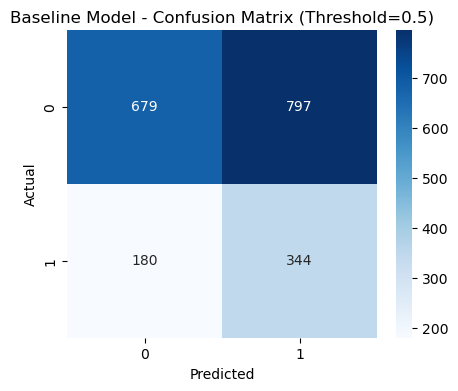

Classification Report (Baseline Model, Threshold=0.5):
              precision    recall  f1-score   support

           0       0.79      0.46      0.58      1476
           1       0.30      0.66      0.41       524

    accuracy                           0.51      2000
   macro avg       0.55      0.56      0.50      2000
weighted avg       0.66      0.51      0.54      2000



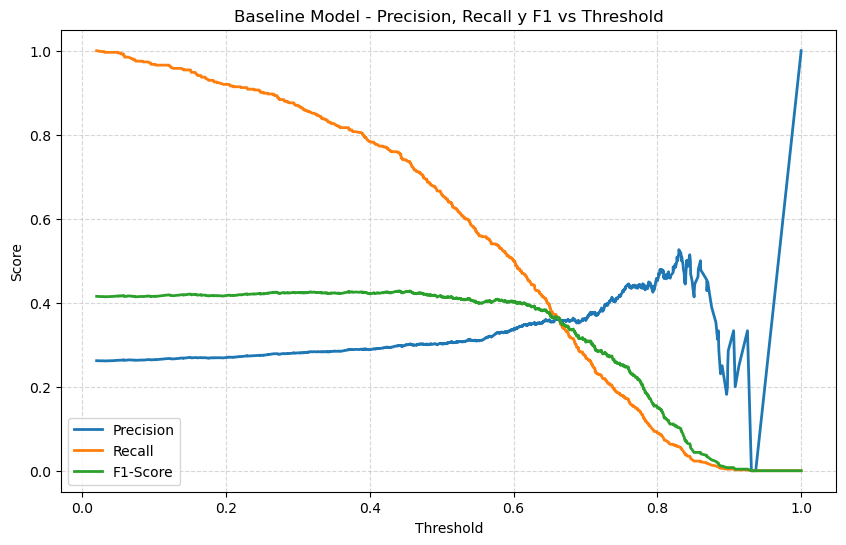

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# ==============================
# BASELINE MODEL PIPELINE
# ==============================
baseline_model = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(
        C=0.1,
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# ==============================
# ENTRENAR BASELINE MODEL
# ==============================
baseline_model.fit(X_abs_f_train, y_abs_f_train)

# ==============================
# PREDICCIONES EN TEST
# ==============================
y_proba = baseline_model.predict_proba(X_abs_f_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

# ==============================
# MATRIZ DE CONFUSIÓN Y REPORT
# ==============================
cm = confusion_matrix(y_abs_f_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline Model - Confusion Matrix (Threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report (Baseline Model, Threshold=0.5):")
print(classification_report(y_abs_f_test, y_pred))

# ==============================
# CALIBRACIÓN DEL THRESHOLD
# ==============================
precision, recall, thresholds = precision_recall_curve(y_abs_f_test, y_proba)
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
thresholds = np.append(thresholds, 1)  # para alinear con precision/recall

df_pr = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision,
    'recall': recall,
    'f1': f1
})

# ==============================
# GRAFICAR PRECISION, RECALL Y F1 VS THRESHOLD
# ==============================
plt.figure(figsize=(10,6))
plt.plot(df_pr['threshold'], df_pr['precision'], label='Precision', lw=2)
plt.plot(df_pr['threshold'], df_pr['recall'], label='Recall', lw=2)
plt.plot(df_pr['threshold'], df_pr['f1'], label='F1-Score', lw=2)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Baseline Model - Precision, Recall y F1 vs Threshold')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



✅ Threshold óptimo según F1: 0.441 con F1=0.428


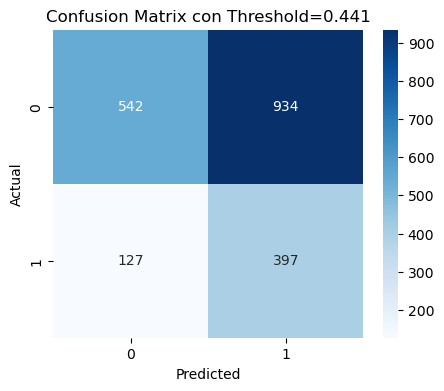


Classification Report con threshold optimizado:
              precision    recall  f1-score   support

           0       0.81      0.37      0.51      1476
           1       0.30      0.76      0.43       524

    accuracy                           0.47      2000
   macro avg       0.55      0.56      0.47      2000
weighted avg       0.68      0.47      0.49      2000



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# ENCONTRAR THRESHOLD ÓPTIMO POR F1
# ==============================
best_idx = df_pr['f1'].idxmax()
best_threshold = df_pr.loc[best_idx, 'threshold']
best_f1 = df_pr.loc[best_idx, 'f1']

print(f"\n✅ Threshold óptimo según F1: {best_threshold:.3f} con F1={best_f1:.3f}")

# ==============================
# APLICAR NUEVO THRESHOLD
# ==============================
y_opt = (y_proba >= best_threshold).astype(int)

# ==============================
# MATRIZ DE CONFUSIÓN Y REPORT FINAL
# ==============================
cm = confusion_matrix(y_abs_f_test, y_opt)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix con Threshold={best_threshold:.3f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report con threshold optimizado:")
print(classification_report(y_abs_f_test, y_opt))

In [67]:
from sklearn.model_selection import StratifiedKFold

fpr_base, tpr_base, _ = roc_curve(y_abs_f_test, y_proba)
roc_auc_base = auc(fpr_base, tpr_base)
precision_base, recall_base, _ = precision_recall_curve(y_abs_f_test, y_proba)

cv = StratifiedKFold(n_splits=5)

# RandomForest

Fitting 5 folds for each of 50 candidates, totalling 250 fits


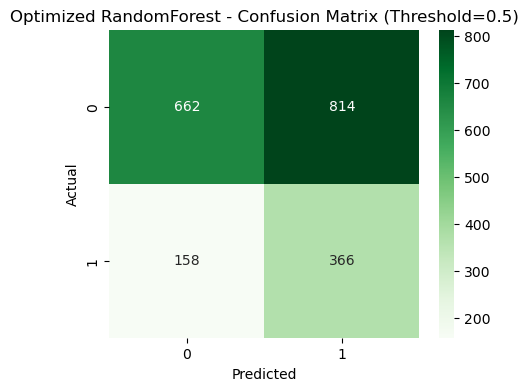

Classification Report (Optimized RandomForest):
              precision    recall  f1-score   support

           0       0.81      0.45      0.58      1476
           1       0.31      0.70      0.43       524

    accuracy                           0.51      2000
   macro avg       0.56      0.57      0.50      2000
weighted avg       0.68      0.51      0.54      2000



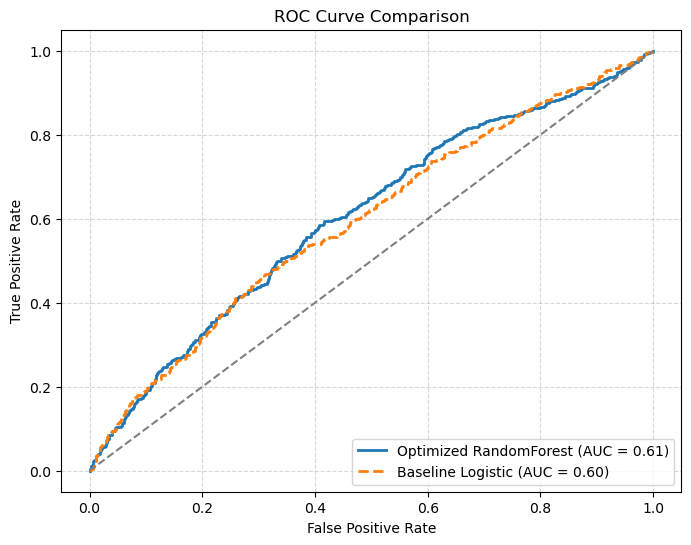

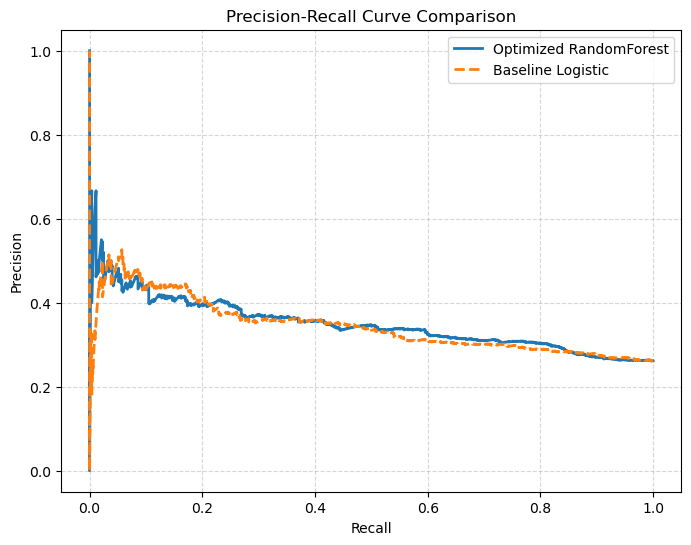


Best Params (RandomForest): {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 11, 'model__class_weight': 'balanced', 'model__bootstrap': True}
Best F1 CV Score (RandomForest): 0.4382211584378277


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# ==============================
# PIPELINE PARA RANDOMFOREST
# ==============================
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(random_state=42))
])

# ==============================
# PARAM GRID EXTENDIDO PARA RANDOM SEARCH
# ==============================
param_dist_rf = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [5, 7, 9, 11],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__bootstrap': [True, False],
    'model__class_weight': ['balanced', {1:2}]
}

# ==============================
# RANDOMIZED SEARCH CV
# ==============================
random_search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# ==============================
# ENTRENAR
# ==============================
random_search_rf.fit(X_abs_f_train, y_abs_f_train)

# ==============================
# EVALUAR EN TEST
# ==============================
y_rf_proba = random_search_rf.predict_proba(X_abs_f_test)[:,1]
y_rf_pred = random_search_rf.predict(X_abs_f_test)

cm_rf = confusion_matrix(y_abs_f_test, y_rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Optimized RandomForest - Confusion Matrix (Threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report (Optimized RandomForest):")
print(classification_report(y_abs_f_test, y_rf_pred))

# ==============================
# COMPARAR CURVAS ROC VS BASELINE
# ==============================
fpr_rf, tpr_rf, _ = roc_curve(y_abs_f_test, y_rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Optimized RandomForest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_base, tpr_base, lw=2, linestyle='--', label=f'Baseline Logistic (AUC = {roc_auc_base:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# COMPARAR CURVAS PRECISION-RECALL VS BASELINE
# ==============================
precision_rf, recall_rf, _ = precision_recall_curve(y_abs_f_test, y_rf_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_rf, precision_rf, lw=2, label='Optimized RandomForest')
plt.plot(recall_base, precision_base, lw=2, linestyle='--', label='Baseline Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# MOSTRAR MEJORES PARÁMETROS DEL RANDOMFOREST
# ==============================
print("\nBest Params (RandomForest):", random_search_rf.best_params_)
print("Best F1 CV Score (RandomForest):", random_search_rf.best_score_)


# XGBoost

Fitting 5 folds for each of 50 candidates, totalling 250 fits


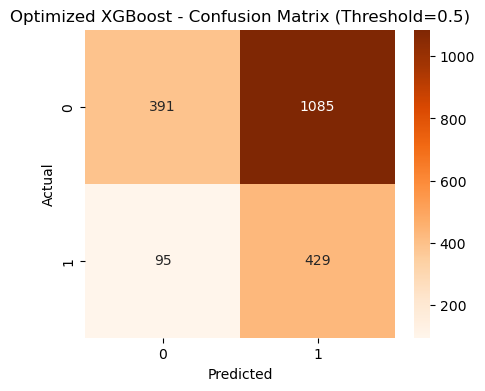

Classification Report (Optimized XGBoost):
              precision    recall  f1-score   support

           0       0.80      0.26      0.40      1476
           1       0.28      0.82      0.42       524

    accuracy                           0.41      2000
   macro avg       0.54      0.54      0.41      2000
weighted avg       0.67      0.41      0.40      2000



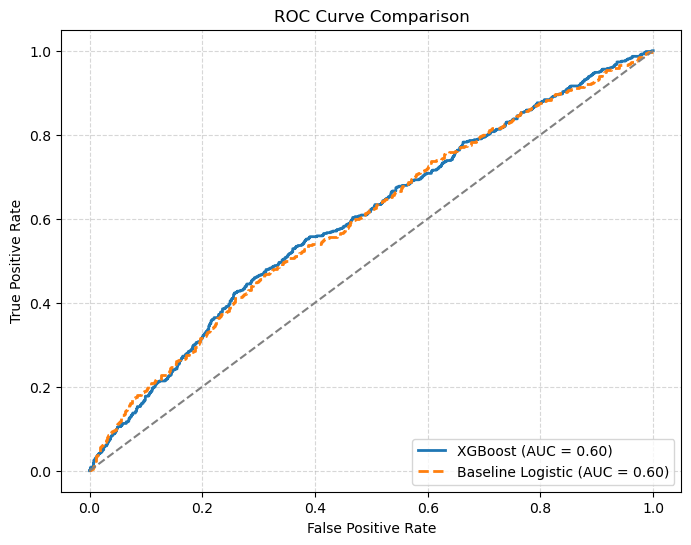

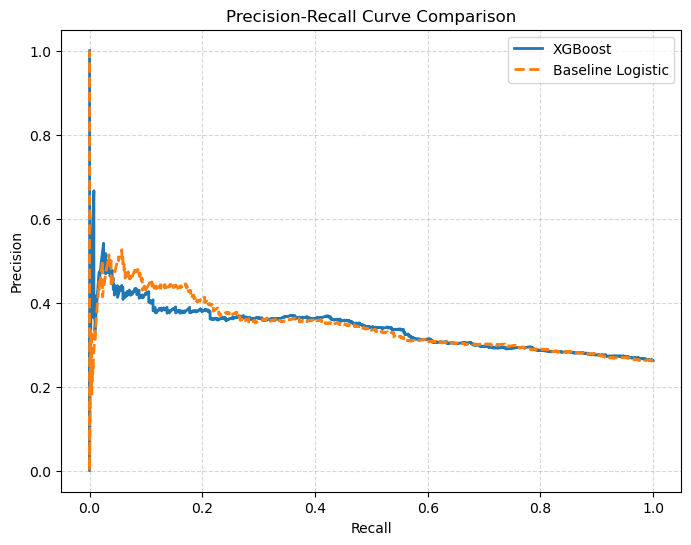


Best Params (XGBoost): {'model__subsample': 1.0, 'model__scale_pos_weight': 3, 'model__n_estimators': 100, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best F1 CV Score (XGBoost): 0.4338253628368964


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# ==============================
# PIPELINE PARA XGBOOST
# ==============================
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# ==============================
# PARAM DIST PARA RANDOMIZED SEARCH
# ==============================
param_dist_xgb = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__scale_pos_weight': [1, 2, 3]  # para desbalance
}

# ==============================
# RANDOMIZED SEARCH
# ==============================
random_search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# ==============================
# ENTRENAR
# ==============================
random_search_xgb.fit(X_abs_f_train, y_abs_f_train)

# ==============================
# EVALUAR EN TEST
# ==============================
y_xgb_proba = random_search_xgb.predict_proba(X_abs_f_test)[:,1]
y_xgb_pred = random_search_xgb.predict(X_abs_f_test)

cm_xgb = confusion_matrix(y_abs_f_test, y_xgb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("Optimized XGBoost - Confusion Matrix (Threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report (Optimized XGBoost):")
print(classification_report(y_abs_f_test, y_xgb_pred))

# ==============================
# COMPARAR CURVAS ROC VS BASELINE
# ==============================
fpr_xgb, tpr_xgb, _ = roc_curve(y_abs_f_test, y_xgb_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_base, tpr_base, lw=2, linestyle='--', label=f'Baseline Logistic (AUC = {roc_auc_base:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# COMPARAR CURVAS PRECISION-RECALL VS BASELINE
# ==============================
precision_xgb, recall_xgb, _ = precision_recall_curve(y_abs_f_test, y_xgb_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_xgb, precision_xgb, lw=2, label='XGBoost')
plt.plot(recall_base, precision_base, lw=2, linestyle='--', label='Baseline Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# MOSTRAR MEJORES PARÁMETROS
# ==============================
print("\nBest Params (XGBoost):", random_search_xgb.best_params_)
print("Best F1 CV Score (XGBoost):", random_search_xgb.best_score_)

# LightGBM

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 4533, number of negative: 1736
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6046
[LightGBM] [Info] Number of data points in the train set: 6269, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.723082 -> initscore=0.959800
[LightGBM] [Info] Start training from score 0.959800
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

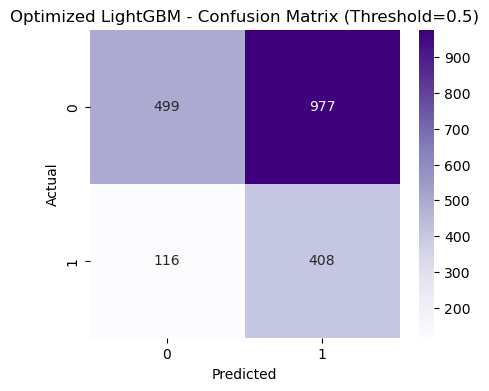

Classification Report (Optimized LightGBM):
              precision    recall  f1-score   support

           0       0.81      0.34      0.48      1476
           1       0.29      0.78      0.43       524

    accuracy                           0.45      2000
   macro avg       0.55      0.56      0.45      2000
weighted avg       0.68      0.45      0.46      2000



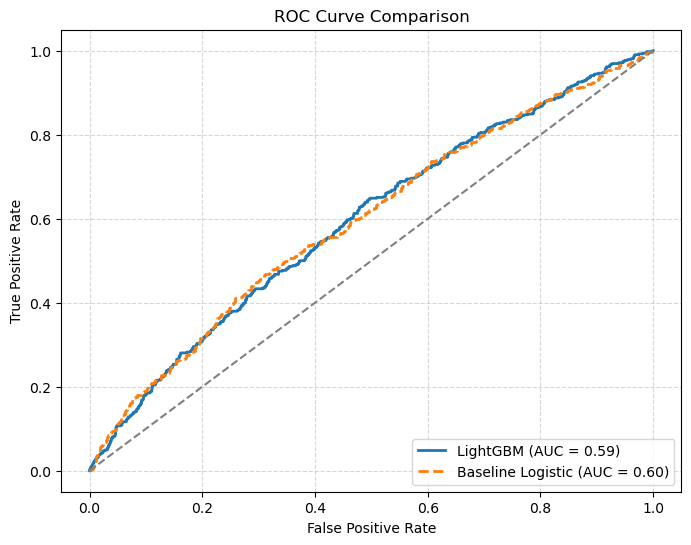

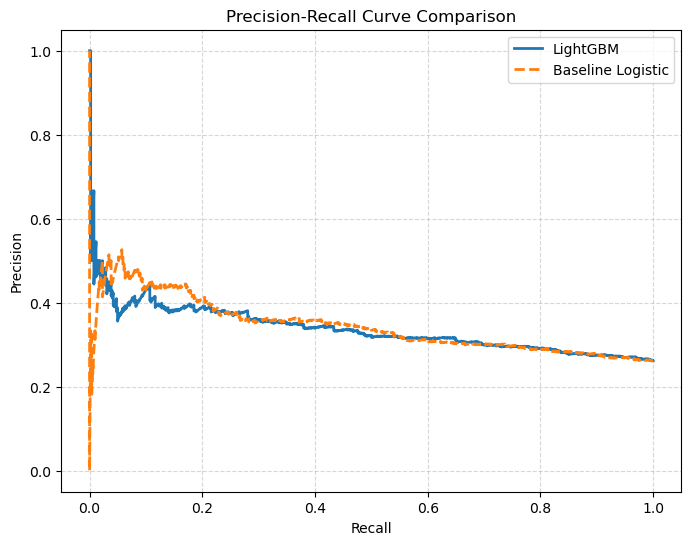


Best Params (LightGBM): {'model__subsample': 1.0, 'model__scale_pos_weight': 3, 'model__n_estimators': 100, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best F1 CV Score (LightGBM): 0.4338253628368964


In [70]:
import lightgbm as lgb

from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

# ==============================
# PIPELINE PARA LightGBM
# ==============================
pipe_lgbm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=5))
])

# ==============================
# PARAM DIST PARA RANDOMIZED SEARCH
# ==============================
param_dist_lgbm = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__min_child_samples': [20, 50],
    'model__num_leaves': [31, 50]
}

# ==============================
# RANDOMIZED SEARCH
# ==============================

random_search_lgbm = RandomizedSearchCV(
    pipe_lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=50,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# ==============================
# ENTRENAR
# ==============================

random_search_lgbm.fit(X_abs_f_train, y_abs_f_train)

# ==============================
# EVALUAR EN TEST
# ==============================
y_lgbm_proba = random_search_lgbm.predict_proba(X_abs_f_test)[:,1]
y_lgbm_pred = random_search_lgbm.predict(X_abs_f_test)

cm_lgbm = confusion_matrix(y_abs_f_test, y_lgbm_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Purples')
plt.title("Optimized LightGBM - Confusion Matrix (Threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report (Optimized LightGBM):")
print(classification_report(y_abs_f_test, y_lgbm_pred))

# ==============================
# COMPARAR CURVAS ROC VS BASELINE
# ==============================
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_abs_f_test, y_lgbm_proba)
roc_auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

plt.figure(figsize=(8,6))
plt.plot(fpr_lgbm, tpr_lgbm, lw=2, label=f'LightGBM (AUC = {roc_auc_lgbm:.2f})')
plt.plot(fpr_base, tpr_base, lw=2, linestyle='--', label=f'Baseline Logistic (AUC = {roc_auc_base:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# COMPARAR CURVAS PRECISION-RECALL VS BASELINE
# ==============================
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_abs_f_test, y_lgbm_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_lgbm, precision_lgbm, lw=2, label='LightGBM')
plt.plot(recall_base, precision_base, lw=2, linestyle='--', label='Baseline Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# MOSTRAR MEJORES PARÁMETROS
# ==============================
print("\nBest Params (LightGBM):", random_search_xgb.best_params_)
print("Best F1 CV Score (LightGBM):", random_search_xgb.best_score_)

# Evaluar modelos

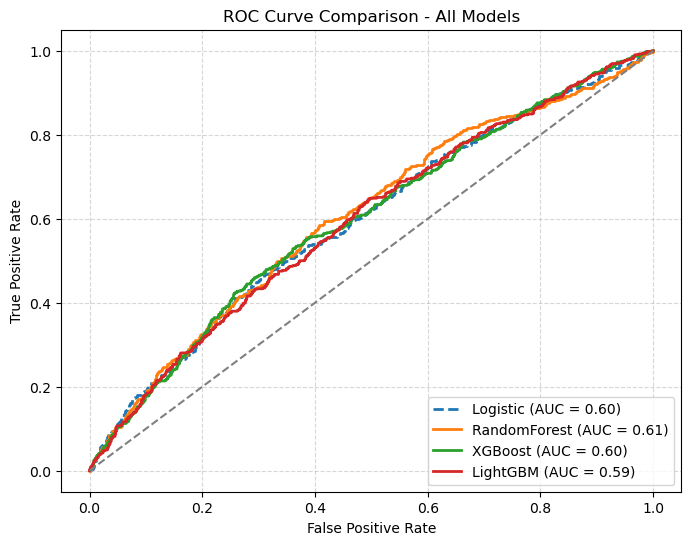

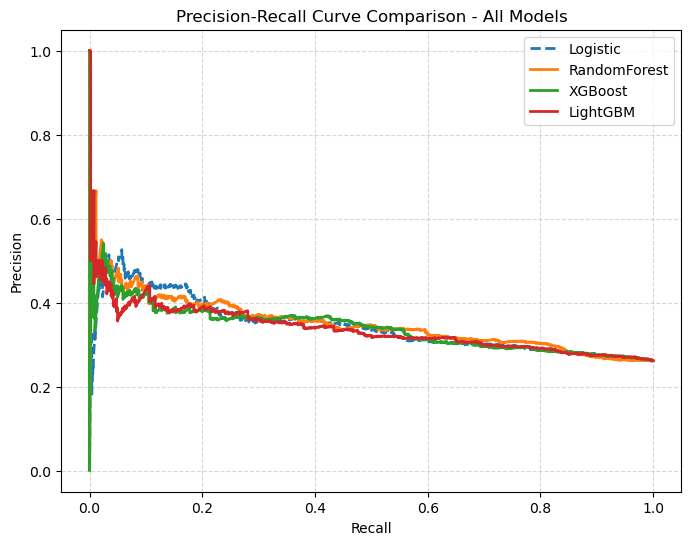

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ==============================
# CURVAS ROC
# ==============================
plt.figure(figsize=(8,6))
plt.plot(fpr_base, tpr_base, lw=2, linestyle='--', label=f'Logistic (AUC = {roc_auc_base:.2f})')
# plt.plot(fpr_svm, tpr_svm, lw=2, linestyle='-', label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot(fpr_rf, tpr_rf, lw=2, linestyle='-', label=f'RandomForest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, lw=2, linestyle='-', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_lgbm, tpr_lgbm, lw=2, linestyle='-', label=f'LightGBM (AUC = {roc_auc_lgbm:.2f})')
# plt.plot(fpr_mlp, tpr_mlp, lw=2, linestyle='-', label=f'Redes Neuronales (AUC = {roc_auc_mlp:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# CURVAS PRECISION-RECALL
# ==============================
plt.figure(figsize=(8,6))
plt.plot(recall_base, precision_base, lw=2, linestyle='--', label='Logistic')
#plt.plot(recall_svm, precision_svm, lw=2, linestyle='-', label='SVM')
plt.plot(recall_rf, precision_rf, lw=2, linestyle='-', label='RandomForest')
plt.plot(recall_xgb, precision_xgb, lw=2, linestyle='-', label='XGBoost')
plt.plot(recall_lgbm, precision_lgbm, lw=2, linestyle='-', label='LightGBM')
# plt.plot(recall_mlp, precision_mlp, lw=2, linestyle='-', label='Redes Neuronales')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison - All Models')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
